# Classification of Consumer Complaints

The Consumer Financial Protection Bureau publishes the Consumer Complaint Database, a collection of complaints about consumer financial products and services that were sent to companies for response. Complaints are published after the company responds, confirming a commercial relationship with the consumer, or after 15 days, whichever comes first. 

You have been provided with a dataset of over 350,000 such complaints for 5 common issue types. Your goal is to train a text classification model to identify the issue type based on the consumer complaint narrative. The data can be downloaded from https://drive.google.com/file/d/1Hz1gnCCr-SDGjnKgcPbg7Nd3NztOLdxw/view?usp=share_link 

As you work, answer the following questions: 
* What steps did you take to preprocess the data?
* How did a model using unigrams compare to one using bigrams or trigrams?
* How did a count vectorizer compare to a tfidf vectorizer?
* What models did you try and how successful were they? Where did they struggle? Were there issues that the models commonly mixed up?
* What words or phrases were most influential on your models' predictions?

In [1]:
import pandas as pd
import numpy as np

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix

In [3]:
complaints = pd.read_csv('data/complaints.csv')
complaints.head(3)

,Consumer complaint narrative,Issue
0,My name is XXXX XXXX this complaint is not mad...,Incorrect information on your report
1,I searched on XXXX for XXXXXXXX XXXX and was ...,Fraud or scam
2,I have a particular account that is stating th...,Incorrect information on your report


To preprocess the data I will need to:
- drop any missing complaints
- make sure everything is lowercase
- remove punctuation and numbers
- remove extra whitespace

In [5]:
complaints = complaints.dropna(subset=['Consumer complaint narrative'])

In [9]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

complaints = complaints.dropna(subset=['Consumer complaint narrative'])

complaints['Consumer complaint narrative'] = (
    complaints['Consumer complaint narrative']
    .astype(str)
    .apply(clean_text)
)

complaints.head(3)

,Consumer complaint narrative,Issue
0,my name is xxxx xxxx this complaint is not mad...,Incorrect information on your report
1,i searched on xxxx for xxxxxxxx xxxx and was p...,Fraud or scam
2,i have a particular account that is stating th...,Incorrect information on your report


## Okay lets create some targets and features

In [12]:
X = complaints['Consumer complaint narrative']
y = complaints['Issue']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 321, stratify = y)

### TF-IDF + Naive Bayes + Unigrams

In [16]:
nb_uni = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,1))),
    ('clf', MultinomialNB())
])

In [23]:
nb_uni.fit(X_train, y_train)

pred_nb_uni = nb_uni.predict(X_test)

print("NB Unigrams")
print("Accuracy:", accuracy_score(y_test, pred_nb_uni))
print(classification_report(y_test, pred_nb_uni))

NB Unigrams
Accuracy: 0.7912130197605197
                                      precision    recall  f1-score   support

   Attempts to collect debt not owed       0.68      0.45      0.54     18291
               Communication tactics       0.90      0.39      0.54      5311
                       Fraud or scam       0.99      0.37      0.54      3087
Incorrect information on your report       0.80      0.98      0.88     57326
          Struggling to pay mortgage       0.96      0.60      0.74      4343

                            accuracy                           0.79     88358
                           macro avg       0.87      0.56      0.65     88358
                        weighted avg       0.79      0.79      0.77     88358



### TF-IDF + Naive Bayes + Bigrams

In [17]:
nb_bi = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2))),
    ('clf', MultinomialNB())
])

In [24]:
nb_bi.fit(X_train, y_train)

pred_nb_bi = nb_bi.predict(X_test)

print("NB Bigrams")
print("Accuracy:", accuracy_score(y_test, pred_nb_bi))
print(classification_report(y_test, pred_nb_bi))

NB Bigrams
Accuracy: 0.6736232146494942
                                      precision    recall  f1-score   support

   Attempts to collect debt not owed       0.75      0.10      0.18     18291
               Communication tactics       0.99      0.05      0.10      5311
                       Fraud or scam       1.00      0.02      0.04      3087
Incorrect information on your report       0.67      1.00      0.80     57326
          Struggling to pay mortgage       1.00      0.00      0.01      4343

                            accuracy                           0.67     88358
                           macro avg       0.88      0.24      0.23     88358
                        weighted avg       0.73      0.67      0.57     88358



### TF-IDF + Logistic Regression + Unigrams

In [18]:
lr_uni = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,1))),
    ('clf', LogisticRegression(max_iter=1000))
])

In [25]:
lr_uni.fit(X_train, y_train)

pred_lr_uni = lr_uni.predict(X_test)

print("LR Unigrams")
print("Accuracy:", accuracy_score(y_test, pred_lr_uni))
print(classification_report(y_test, pred_lr_uni))

LR Unigrams
Accuracy: 0.8821838430023314
                                      precision    recall  f1-score   support

   Attempts to collect debt not owed       0.77      0.71      0.74     18291
               Communication tactics       0.85      0.77      0.81      5311
                       Fraud or scam       0.93      0.87      0.90      3087
Incorrect information on your report       0.91      0.95      0.93     57326
          Struggling to pay mortgage       0.93      0.91      0.92      4343

                            accuracy                           0.88     88358
                           macro avg       0.88      0.84      0.86     88358
                        weighted avg       0.88      0.88      0.88     88358



### TF-IDF + Logistic Regression + Bigrams

In [19]:
lr_bi = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2))),
    ('clf', LogisticRegression(max_iter=1000))
])

In [27]:
lr_bi.fit(X_train, y_train)

pred_lr_bi = lr_bi.predict(X_test)

print("LR Bigrams")
print("Accuracy:", accuracy_score(y_test, pred_lr_bi))
print(classification_report(y_test, pred_lr_bi))

LR Bigrams
Accuracy: 0.8958328617669028
                                      precision    recall  f1-score   support

   Attempts to collect debt not owed       0.80      0.74      0.77     18291
               Communication tactics       0.86      0.78      0.82      5311
                       Fraud or scam       0.94      0.87      0.90      3087
Incorrect information on your report       0.92      0.96      0.94     57326
          Struggling to pay mortgage       0.93      0.91      0.92      4343

                            accuracy                           0.90     88358
                           macro avg       0.89      0.85      0.87     88358
                        weighted avg       0.89      0.90      0.89     88358



## Lets compare models

In [28]:
from sklearn.metrics import accuracy_score

pred_nb_uni = nb_uni.predict(X_test)
print("NB Uni:", accuracy_score(y_test, pred_nb_uni))

pred_nb_bi = nb_bi.predict(X_test)
print("NB Bi:", accuracy_score(y_test, pred_nb_bi))

pred_lr_uni = lr_uni.predict(X_test)
print("LR Uni:", accuracy_score(y_test, pred_lr_uni))

pred_lr_bi = lr_bi.predict(X_test)
print("LR Bi:", accuracy_score(y_test, pred_lr_bi))

NB Uni: 0.7912130197605197
NB Bi: 0.6736232146494942
LR Uni: 0.8821838430023314
LR Bi: 0.8958328617669028


since the **Logistic Regression and Bigrams** model is the best we will work with that one and create the **confusion matrix**

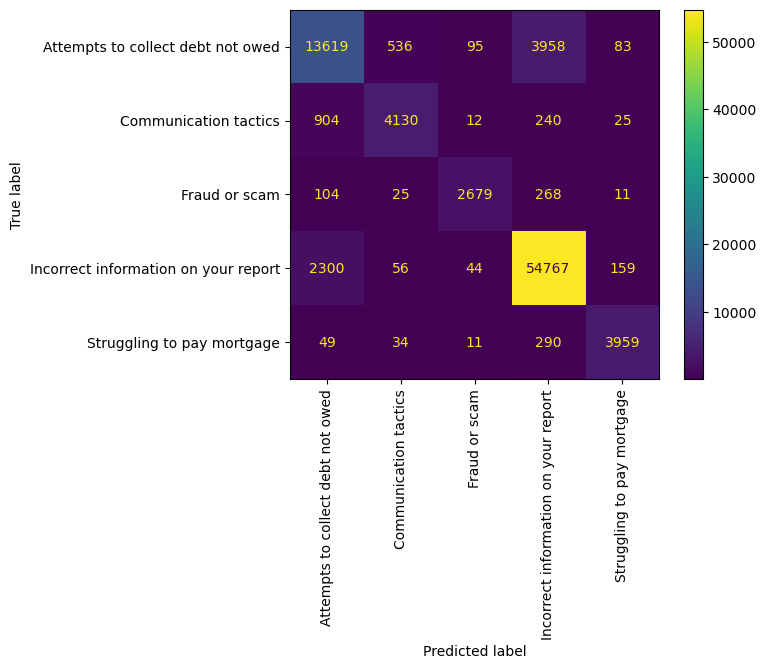

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_bi.predict(X_test),
    xticks_rotation=90
)

Common and Most influential words

In [36]:
feature_names = lr_bi.named_steps['tfidf'].get_feature_names_out()
classifier = lr_bi.named_steps['clf']

In [37]:
for i, category in enumerate(classifier.classes_):
    top = classifier.coef_[i].argsort()[-10:]
    print(category)
    print(feature_names[top])

Attempts to collect debt not owed
['theft' 'account' 'this' 'paid' 'collections' 'owed' 'credit' 'owe'
 'collection' 'debt']
Communication tactics
['called me' 'collection' 'rude' 'day' 'cease' 'repeatedly' 'debt' 'call'
 'calling' 'calls']
Fraud or scam
['app' 'refund' 'scammed' 'wire' 'paypal' 'scam' 'transfer' 'funds'
 'coinbase' 'money']
Incorrect information on your report
['inquiries' 'incorrect' 'reported' 'late' 'report' 'credit' 'transunion'
 'equifax' 'reporting' 'experian']
Struggling to pay mortgage
['behind' 'my mortgage' 'loan' 'sale' 'forbearance' 'home' 'my home'
 'foreclosure' 'modification' 'mortgage']


The most influential words were extracted from the coefficients of the Logistic Regression model. Features with the highest positive weights were identified for each class, indicating the words that most strongly influenced predictions.

**Classification of Consumer Complaints – My Final Report**
1. Data Preprocessing
- Removed rows with missing values in Consumer complaint narrative column.
- Converted text to lowercase.
- Removed punctuation, numbers, and special characters.
- Removed extra whitespace.
- Split dataset into training (80%) and testing (20%) sets with stratification.

2. Unigrams vs Bigrams
Naive Bayes (Unigrams): 0.7912
Naive Bayes (Bigrams): 0.6736
Logistic Regression (Unigrams): 0.8822
Logistic Regression (Bigrams): 0.8958 (Best Model)
Bigrams improved Logistic Regression but hurt Naive Bayes due to independence assumptions.

3. Count Vectorizer vs TF-IDF
- Count Vectorizer uses raw word counts.
- TF-IDF weights words by importance across documents.
- TF-IDF reduces impact of common words and improves classification performance.

4. Models Tested
- Naive Bayes: fast baseline, lower accuracy.
- Logistic Regression: strongest performer.
- Common confusion between fraud vs incorrect reporting and debt collection vs credit reporting.

5. Best Model
- Logistic Regression with TF-IDF bigrams (Accuracy: 0.8958).
- Best due to ability to capture meaningful phrases and weighted features.

6. Most Influential Words
- Credit reporting: credit report, equifax, experian
- Fraud: fraud, scam, unauthorized, identity theft
- Debt collection: debt collection, collection agency
- Mortgage: foreclosure, escrow, loan modification
- Credit card: late fee, interest rate, balance transfer

**Bonus:** A larger dataset containing 20 additional categories can be downloaded from https://drive.google.com/file/d/1gW6LScUL-Z7mH6gUZn-1aNzm4p4CvtpL/view?usp=share_link. How well do your models work with these additional categories?